# Selfish vs Altruistic Agents

This experiment involves two agents engaged in travel, each with distinct preferences: selfish agents seek to maximize their individual travel time, while altruistic agents aim to maximize the average travel time between them. The chosen origin-destination pairs for travel are deliberately distant. The experiment utilizes the Proximal Policy Optimization (PPO) algorithm for learning in both scenarios. 

## Experiment Summary

- **Paths:** Three distinct routes considered for each origin-destination pair.
- **Network Architecture:** Utilization of the Csomor network.
- **Reinforcement Learning Algorithm:** Proximal Policy Optimization (PPO)

    - **PPO Hyperparameters:**
        - *Gamma:* 0.9
        - *Learning Rate:* 1e-3


## Altruistic Agents

In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [109.88081399626681, 341.35534716542634, 249.38627326722172], (0, 1): [95.67452186007033, 239.4662866046373, 69.68273551107882], (1, 0): [167.05033031797063, 100.05134975942387, 24.830201415303055], (1, 1): [75.50123699705149, 1925.0537917948654, 2172.4368972004117]}
[SUCCESS] Free flow times calculated!


In [5]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [6]:
env.reward_table = []
env.actions = []
env.actions2 = []        

In [7]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [8]:
model.learn(total_timesteps=2000)

----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 301 |
|    total_timesteps | 20  |
----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 0            |
|    iterations           | 2            |
|    time_elapsed         | 556          |
|    total_timesteps      | 40           |
| train/                  |              |
|    approx_kl            | 0.0013837039 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 1.17e-05     |
|    learning_rate        | 0.001        |
|    loss                 | 7.71e+05     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0191      |
|    value_loss           | 1.98e+06     |
------------------------------------------
-----------------------

Reward table is:  [-1773.8249999999998, -1773.8249999999998, -262.2583333333333, -1553.575, -1553.575, -1773.8249999999998, -1725.4416666666666, -1553.575, -124.28333333333333, -262.2583333333333, -1773.8249999999998, -1416.1333333333332, -1553.575, -124.28333333333333, -1416.1333333333332, -1505.0500000000002, -213.975, -1635.775, -213.975, -213.975, -1725.4416666666666, -124.28333333333333, -1505.0500000000002, -1553.575, -1416.1333333333332, -124.28333333333333, -1635.775, -1725.4416666666666, -124.28333333333333, -213.975, -1416.1333333333332, -213.975, -1635.775, -1505.0500000000002, -1416.1333333333332, -1416.1333333333332, -1725.4416666666666, -1553.575, -1773.8249999999998, -213.975, -213.975, -1416.1333333333332, -124.28333333333333, -213.975, -124.28333333333333, -213.975, -1725.4416666666666, -1773.8249999999998, -262.2583333333333, -124.28333333333333, -1635.775, -124.28333333333333, -262.2583333333333, -124.28333333333333, -1635.775, -1635.775, -1553.575, -1773.82499999999

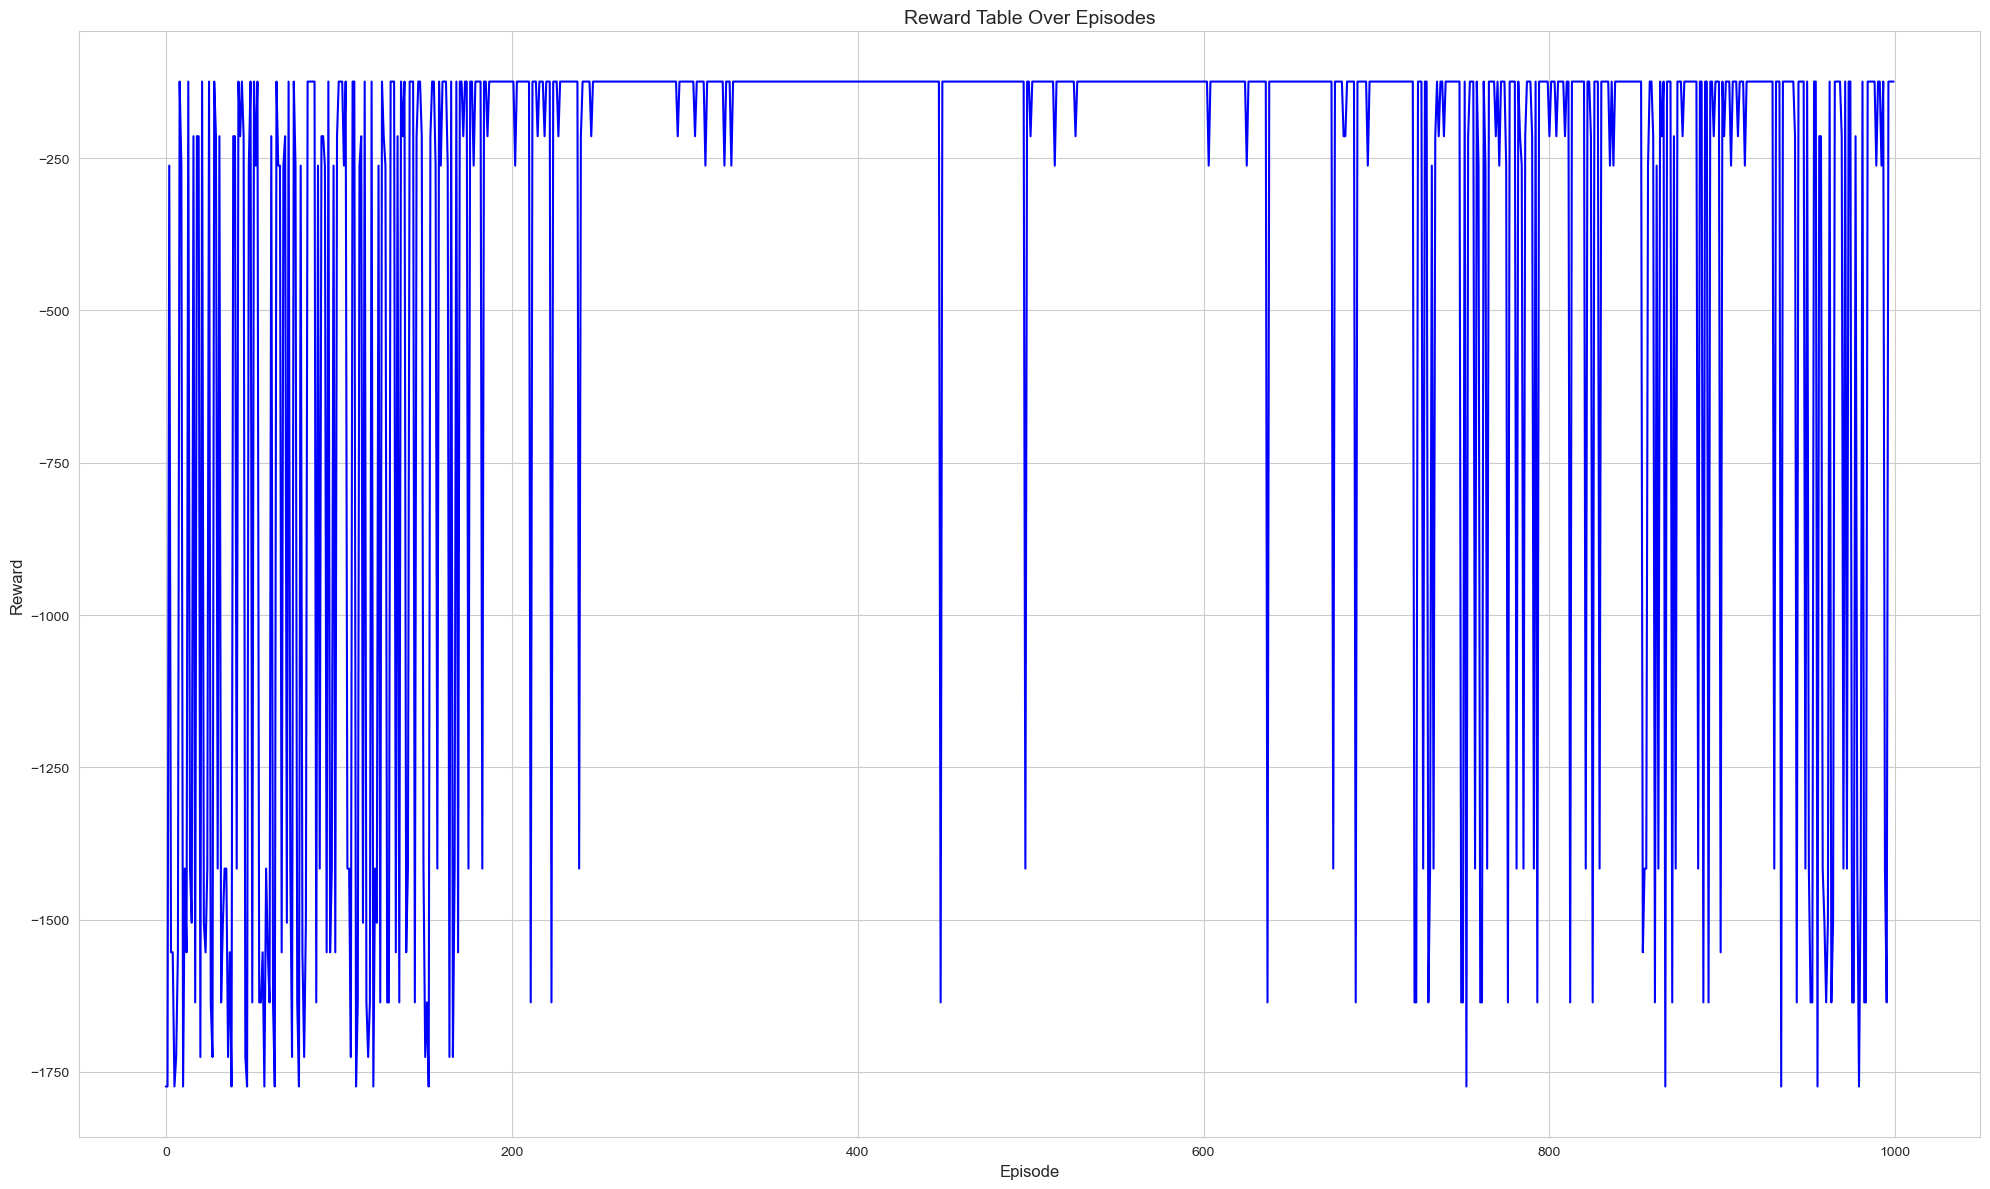

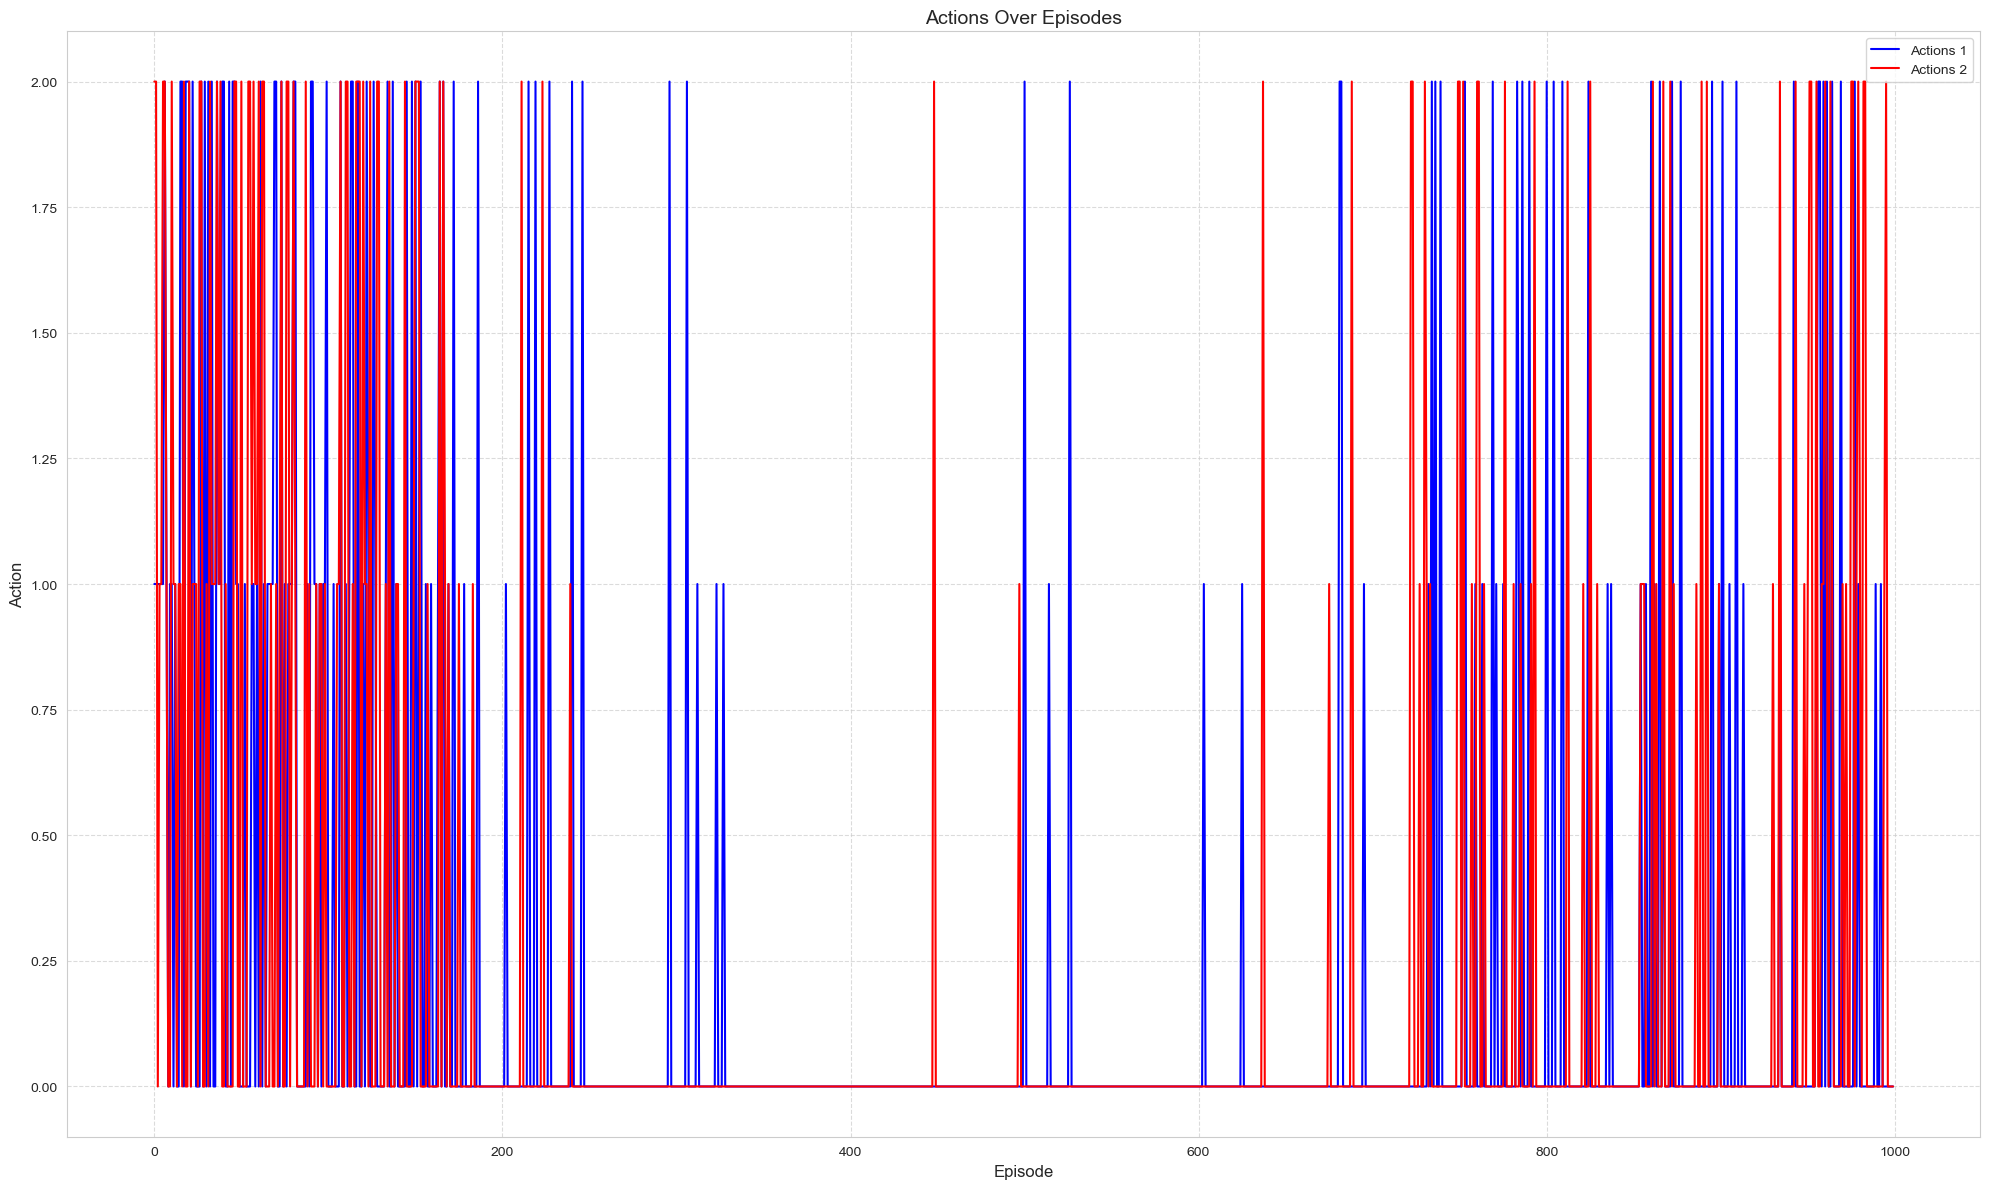

In [9]:
env.close()

## Selfish Agents

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [24.552663176386666, 206.16804711064245, 217.34135132103702], (0, 1): [398.2693150576001, 2217.8306113242056, 37.292056894752115], (1, 0): [162.89345307817914, 5.017127599650358, 1233.5646313262862], (1, 1): [223.62242158494766, 56.36108027140517, 463.4032191981847]}
[SUCCESS] Free flow times calculated!
Agent 0 has origin 1 and destination 1.
Agent 1 has origin 0 and destination 1.


In [5]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [10]:
env.reward_table = []
env.reward_table2 = []
env.actions = []
env.actions2 = []        

In [11]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    **tuned_params
)

Using cpu device


In [12]:
model.learn(total_timesteps=10)

----------------------------
| time/              |     |
|    fps             | 0   |
|    iterations      | 1   |
|    time_elapsed    | 324 |
|    total_timesteps | 20  |
----------------------------


Reward table is:  [-69.98333333333333, -284.0, -586.65, -285.51666666666665, -70.06666666666666, -284.0, -69.98333333333333, -284.0, -586.65, -284.0, -70.06666666666666, -586.5666666666667, -586.5666666666667, -284.01666666666665, -586.6833333333333, -285.51666666666665, -285.51666666666665, -586.65, -70.06666666666666, -586.65, -70.06666666666666, -586.6833333333333, -284.01666666666665, -284.01666666666665, -70.06666666666666, -285.51666666666665, -70.06666666666666, -284.0, -285.51666666666665, -284.0, -586.5666666666667, -285.51666666666665, -586.65, -69.98333333333333, -586.6833333333333, -586.5666666666667, -69.98333333333333, -69.98333333333333, -285.51666666666665, -586.5666666666667, -70.06666666666666, -70.06666666666666, -284.0, -284.0, -586.65, -69.98333333333333, -586.65, -285.51666666666665, -70.06666666666666, -586.65, -586.6833333333333, -70.06666666666666, -586.6833333333333, -284.01666666666665, -69.98333333333333, -69.98333333333333, -70.06666666666666, -586.65, -70.

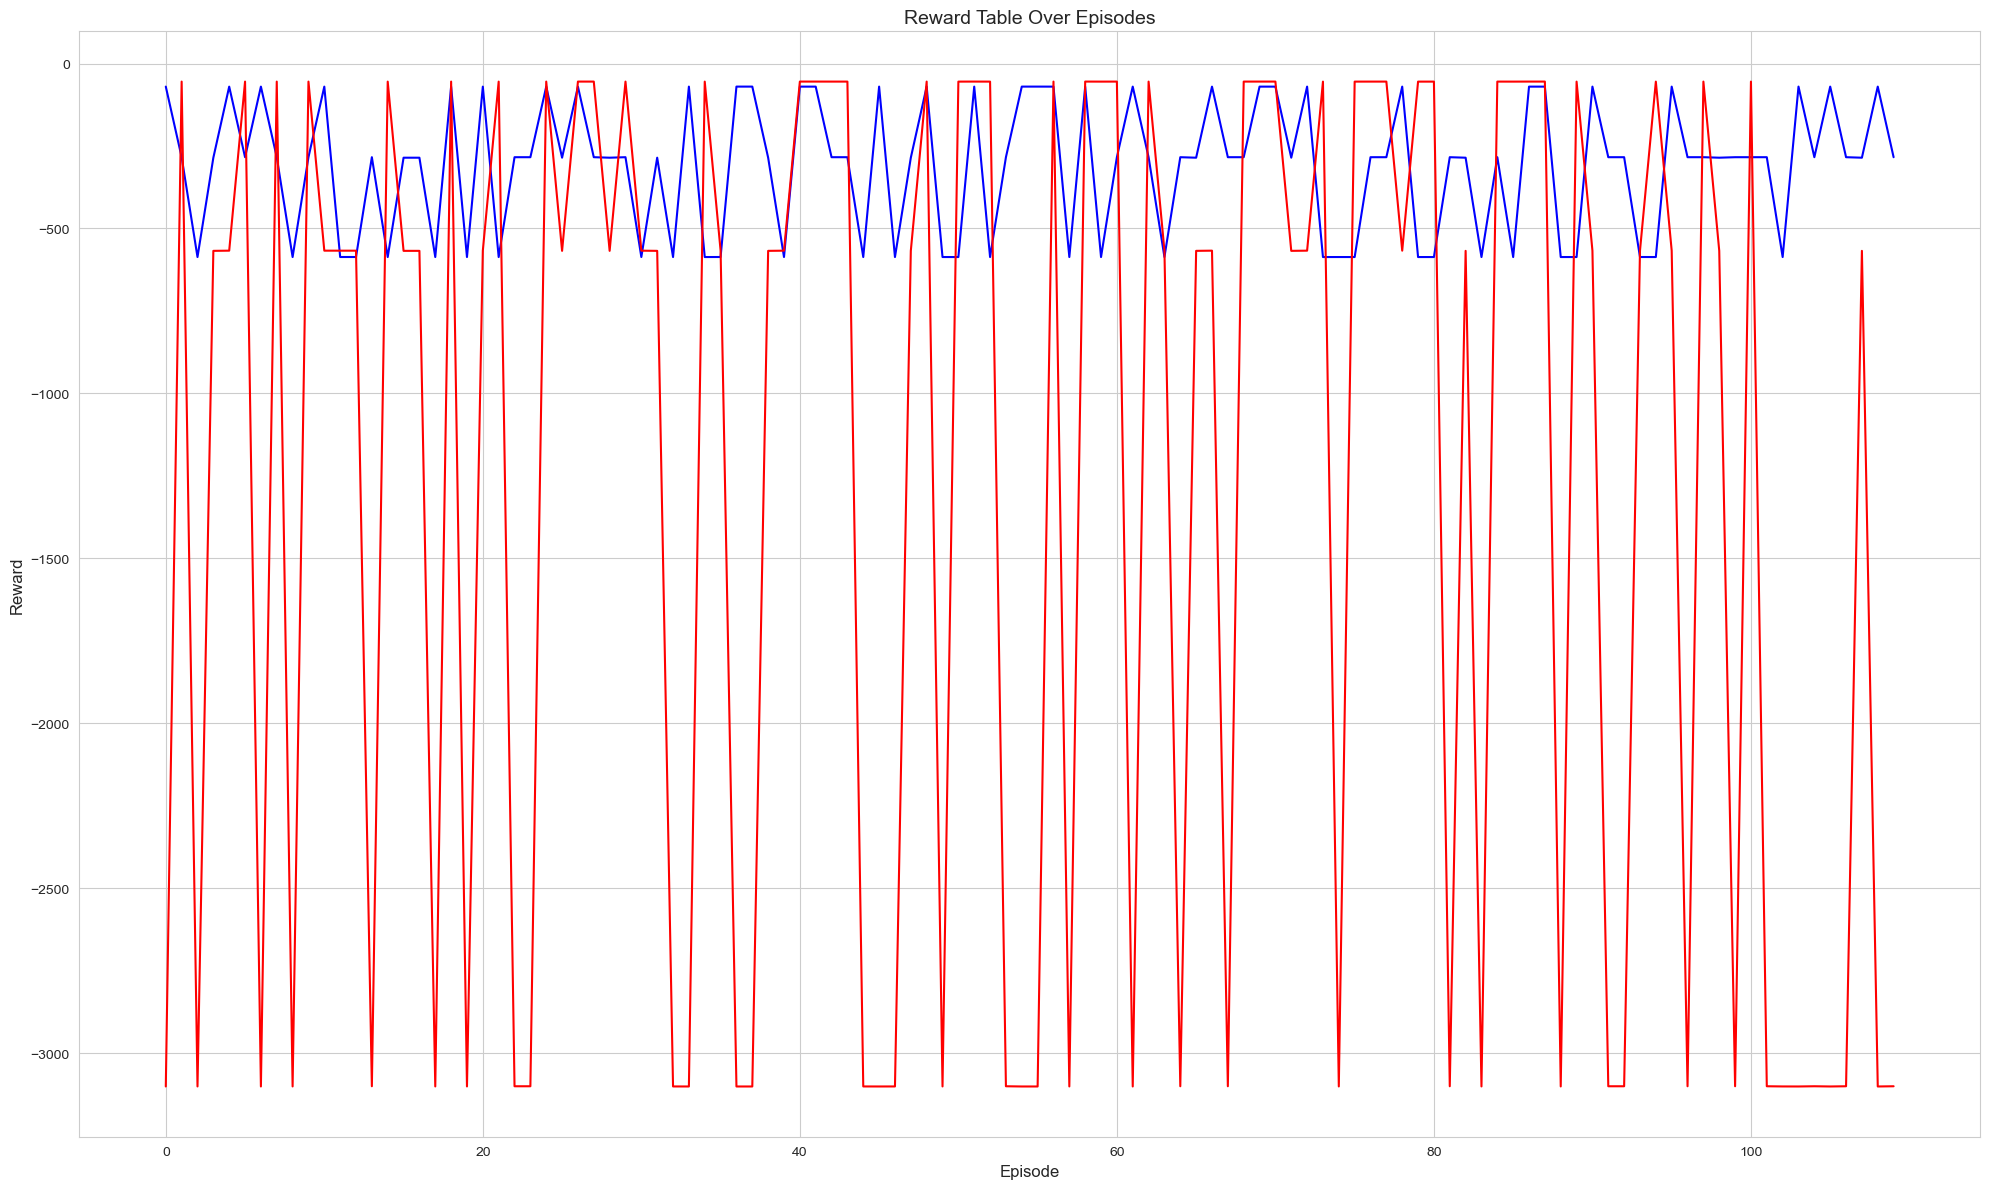

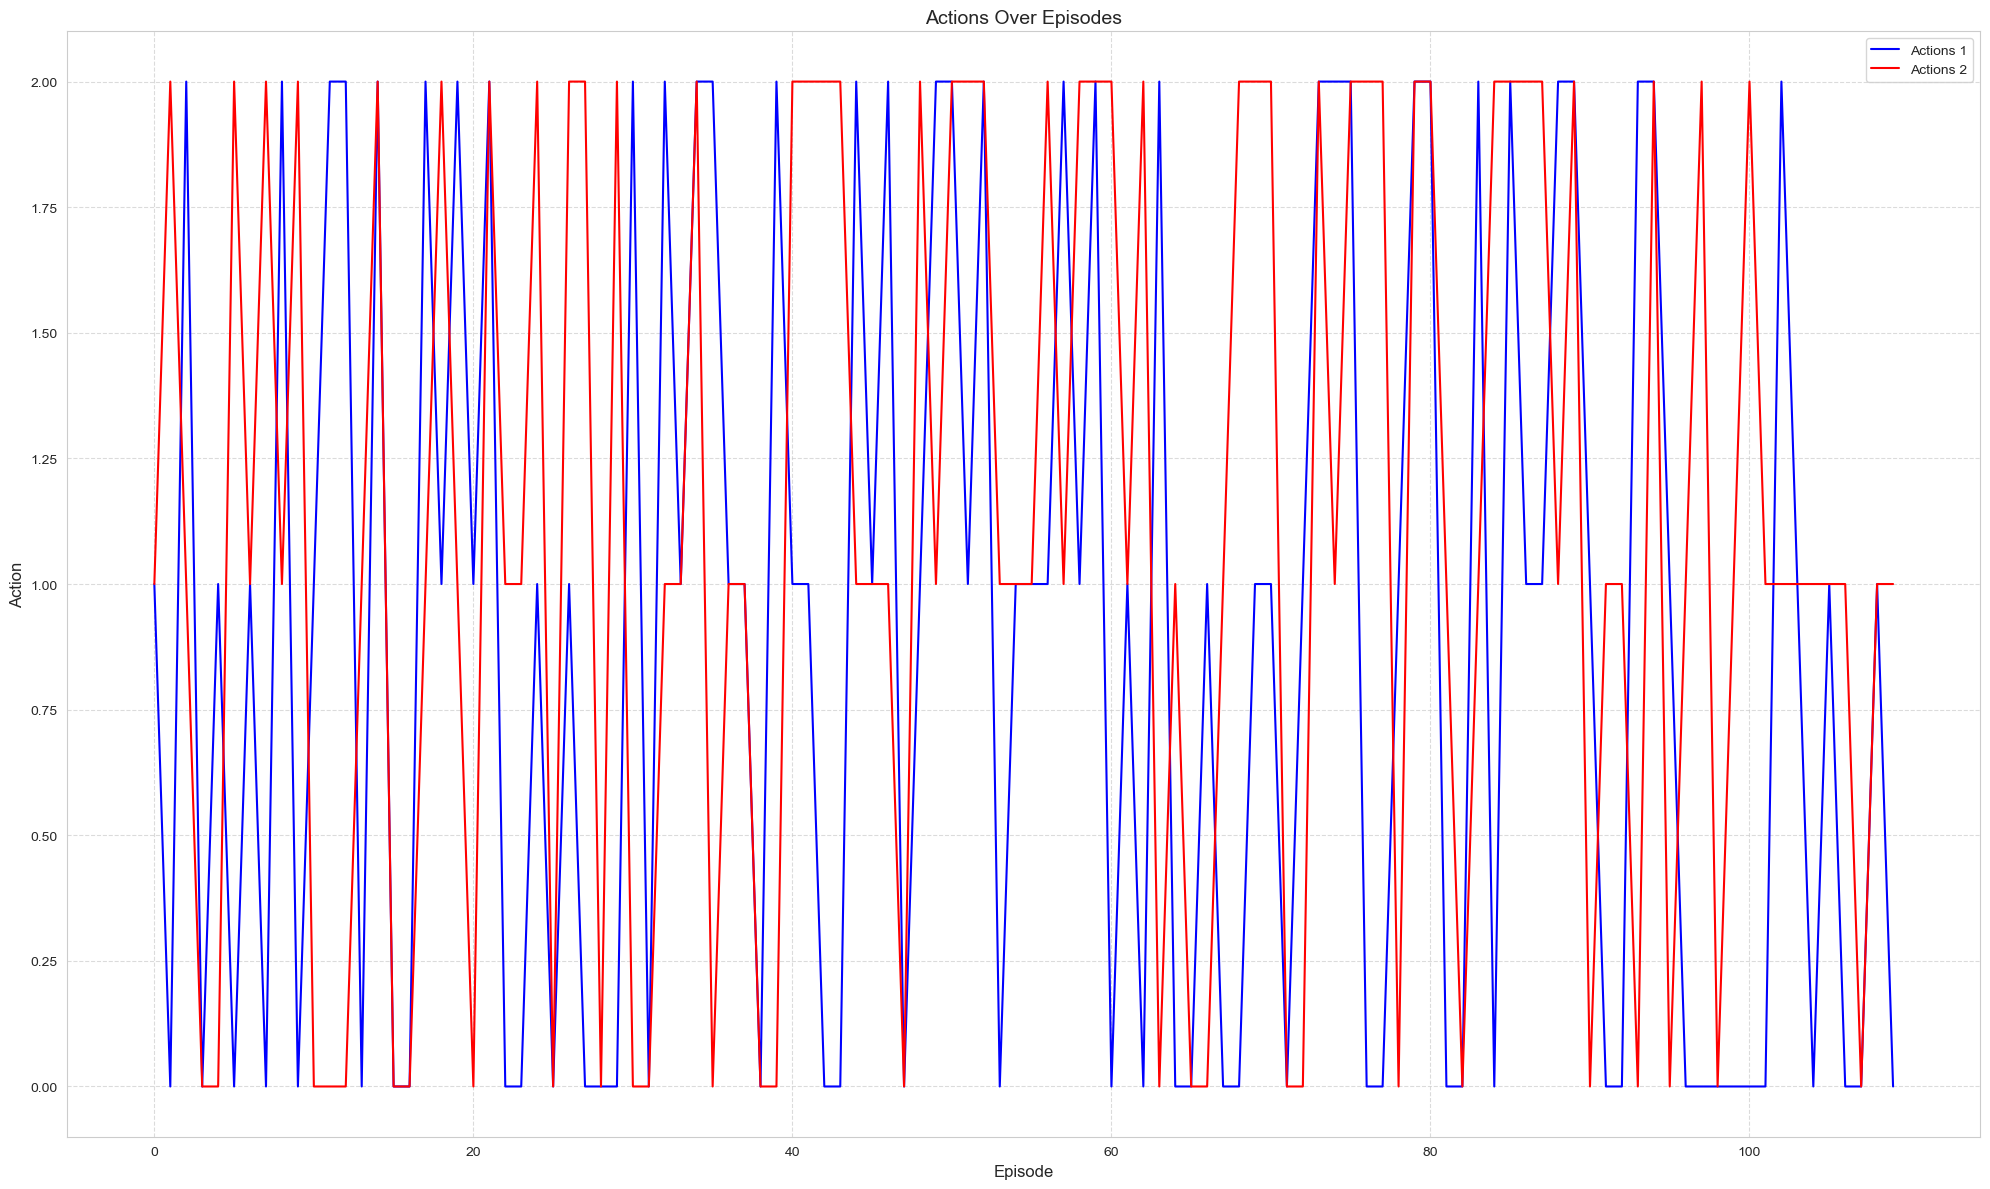

In [14]:
env.close()